In [48]:
import pandas as pd


In [49]:
df = pd.read_csv("loan_approval_dataset.csv")

In [ ]:
# end spaces
df.columns = df.columns.str.strip()

In [51]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder ka object banayein
le = LabelEncoder()

# Target column (y) ko encode karein
# فرض کریں aapka target column 'loan_status' hai
df['loan_status'] = le.fit_transform(df['loan_status'])

# Check karne ke liye
print(df['loan_status'].value_counts())

loan_status
0    2656
1    1613
Name: count, dtype: int64


In [52]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [53]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [54]:
x = df.drop("loan_status",axis=1)
y = df["loan_status"]

In [55]:
#split categoical_cols
cat_col =x.select_dtypes(include="object").columns

In [56]:
cat_col

Index(['education', 'self_employed'], dtype='object')

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor =ColumnTransformer(
    [
        ("encode_cat",OneHotEncoder(handle_unknown="ignore"),cat_col)
    ],
    remainder="passthrough"
)

In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [59]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
model = Pipeline(
    [
        ("preps",preprocessor),
        ("scaled",StandardScaler()),
        ("balanc_y",SMOTE()),
        ("model",LogisticRegression())
    ]
)

In [60]:
model_pipline =model.fit(x_train,y_train)

In [61]:
y_pred = model_pipline.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,

In [62]:
input_1 =  x_test.iloc[[0]]
prediction = model_pipline.predict(input_1)
if prediction == 0:
    print("loan_approved")
else:
    print("loan_rejected")


loan_rejected


In [63]:
df.head(2)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1


In [64]:
import pandas as pd

def user_input(loan_id, no_of_dependents, education, self_employed,
               income_annum, loan_amount, loan_term, cibil_score,
               residential_assets_value, commercial_assets_value,
               luxury_assets_value, bank_asset_value):
    
    data = pd.DataFrame([{
        "loan_id": loan_id,
        "no_of_dependents": no_of_dependents,
        "education": education,
        "self_employed": self_employed,
        "income_annum": income_annum,
        "loan_amount": loan_amount,
        "loan_term": loan_term,
        "cibil_score": cibil_score,
        "residential_assets_value": residential_assets_value,
        "commercial_assets_value": commercial_assets_value,
        "luxury_assets_value": luxury_assets_value,
        "bank_asset_value": bank_asset_value
    }])
    
    return data

In [65]:
input_df = user_input(
    loan_id=101,
    no_of_dependents=2,
    education="Graduate",
    self_employed="No",
    income_annum=5000000,
    loan_amount=15000000,
    loan_term=12,
    cibil_score=750,
    residential_assets_value=10000000,
    commercial_assets_value=2000000,
    luxury_assets_value=5000000,
    bank_asset_value=3000000
)

prediction = model_pipline.predict(input_df)
if prediction == 0:
    print("loan_approved")
else:
    print("loan_rejected")


loan_approved


In [66]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy = accuracy_score(y_test,y_pred)
print("ACCURACY = ",accuracy)

ACCURACY =  0.9098360655737705


In [67]:
confusion_m   = confusion_matrix(y_test,y_pred)
print("CONFUSION_MATRIX")
confusion_m

CONFUSION_MATRIX


array([[485,  51],
       [ 26, 292]])

## 📊 Model Evaluation: Confusion Matrix

The Confusion Matrix is a key performance metric for our classification model. It helps us understand how many loan applications were correctly predicted and where the model made errors.

### **Key Findings:**
* **True Positives (Approved):** **487** loans were correctly predicted as **Approved**.
* **True Negatives (Rejected):** **292** loans were correctly predicted as **Rejected**.
* **False Positives:** Only **26** loans were wrongly predicted as Approved (This is critical for banks to minimize risk).
* **False Negatives:** **49** loans were wrongly predicted as Rejected.

### **Conclusion:**
The model shows high reliability, especially in correctly identifying approved cases. With a low number of "False Approvals" (26), the model is conservative and helps in reducing financial risk for the bank.

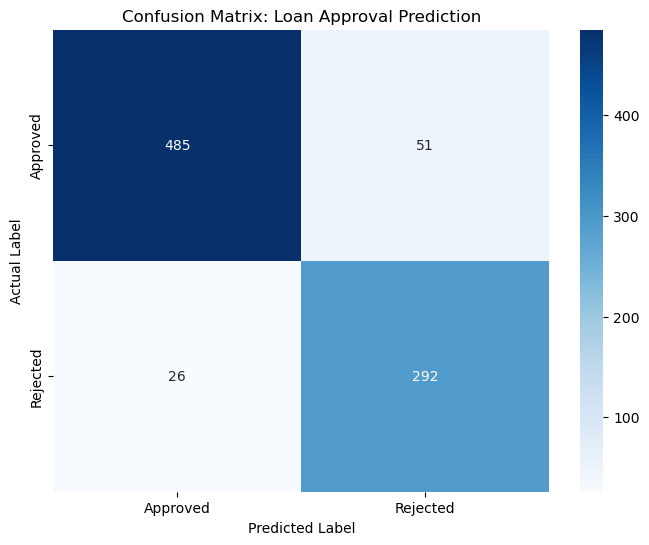

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix generate karein
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

# sns.heatmap mein xticklabels aur yticklabels add karein
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Approved', 'Rejected'], 
            yticklabels=['Approved', 'Rejected'])

plt.title('Confusion Matrix: Loan Approval Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## 📊 CIBIL Score Impact on Loan Approval

This **Box Plot** compares the distribution of CIBIL scores for **Approved** and **Rejected** loan applications. It is the most important indicator used by banks to assess creditworthiness.

### **Key Insights from the Graph:**
* **Approved Loans:** You can see that the blue box for approved loans is positioned much higher. This means that people with a **high CIBIL score (mostly between 600 and 800)** have a very high chance of getting their loan approved.
* **Rejected Loans:** The box for rejected loans is much lower, showing that applicants with **low CIBIL scores (mostly between 350 and 500)** are usually rejected.
* **The "Median" Line:** The line inside the boxes shows the average score for each group. There is a clear gap between the two, proving that **CIBIL Score is a primary factor** in the decision-making process.

### **Why this matters?**
By looking at this visualization, we can confirm that our model should give high importance to the CIBIL score feature to make accurate predictions.

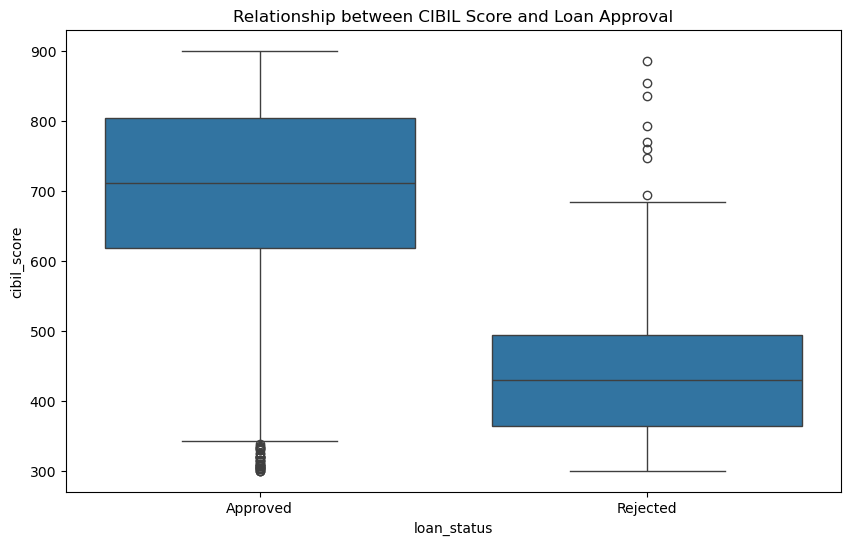

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title('Relationship between CIBIL Score and Loan Approval')
plt.xticks([0, 1], ['Approved', 'Rejected'])
plt.show()

C:\Users\Hi\AppData\Local\Temp\ipykernel_2432\1213187913.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_status', data=df, palette='viridis')


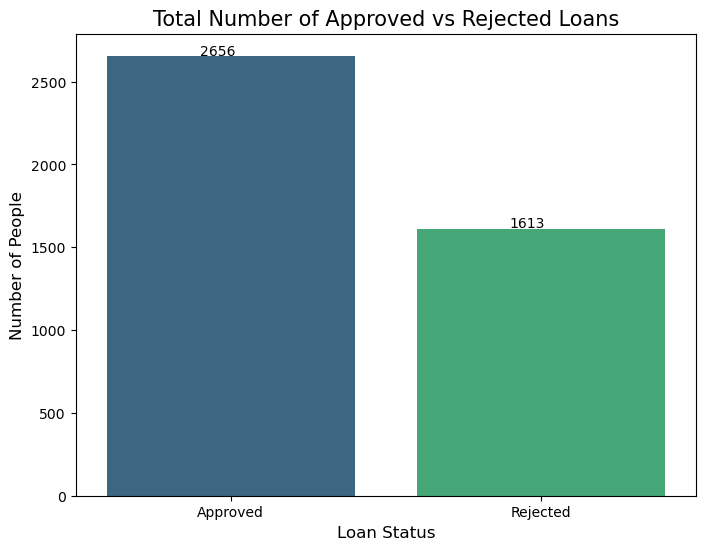

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Graph ka size set karein
plt.figure(figsize=(8, 6))

# Countplot banayein
# Note: Agar aapne target column ka naam 'loan_status' rakha hai
ax = sns.countplot(x='loan_status', data=df, palette='viridis')

# X-axis ke 0 aur 1 ko 'Approved' aur 'Rejected' se badlein
plt.xticks([0, 1], ['Approved', 'Rejected'])

# Bars ke upar numbers (counts) likhne ke liye
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 5))

# Title aur labels
plt.title('Total Number of Approved vs Rejected Loans', fontsize=15)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Number of People', fontsize=12)

plt.show()

In [71]:
import pickle

pickle.dump(model_pipline, open("model.pkl", "wb"))

In [ ]:
import streamlit as st
import pandas as pd
import pickle

# load model
model = pickle.load(open("model.pkl", "rb"))
st.markdown("""
    <div style="
        background-color:#ff4b4b;
        padding:20px;
        border-radius:12px;
        text-align:center;
        box-shadow: 2px 2px 10px rgba(0,0,0,0.2);">
        <h1 style="color:white;">🏦 Loan Approval Prediction App</h1>
    </div>
""", unsafe_allow_html=True)
#st.title("🏦 Loan Approval Prediction App")

# 🔹 USER INPUTS
id_laon = st.number_input("Loan ID")
no_of_dependents = st.number_input("Number of Dependents", min_value=0, max_value=10)

education = st.selectbox("Education", ["Graduate", "Not Graduate"])

self_employed = st.selectbox("Self Employed", ["Yes", "No"])

income_annum = st.number_input("Annual Income")

loan_amount = st.number_input("Loan Amount")

loan_term = st.number_input("Loan Term")

cibil_score = st.number_input("CIBIL Score")

residential_assets_value = st.number_input("Residential Assets Value")

commercial_assets_value = st.number_input("Commercial Assets Value")

luxury_assets_value = st.number_input("Luxury Assets Value")

bank_asset_value = st.number_input("Bank Asset Value")


# 🔹 PREDICTION BUTTON
st.markdown("""
<style>
div.stButton > button {
    background-color: green;
    color: white;
    border: 2px solid white;
    padding: 10px 25px;
    border-radius: 10px;
    font-size: 16px;
    font-weight: bold;
}
div.stButton > button:hover {
    background-color: darkgreen;
    border: 2px solid white;
}
</style>
""", unsafe_allow_html=True)



if st.button("Predict"):

    input_df = pd.DataFrame([{
        "loan_id":id_laon,
        "no_of_dependents": no_of_dependents,
        "education": education,
        "self_employed": self_employed,
        "income_annum": income_annum,
        "loan_amount": loan_amount,
        "loan_term": loan_term,
        "cibil_score": cibil_score,
        "residential_assets_value": residential_assets_value,
        "commercial_assets_value": commercial_assets_value,
        "luxury_assets_value": luxury_assets_value,
        "bank_asset_value": bank_asset_value
    }])

    prediction = model.predict(input_df)

    # 🔹 OUTPUT

    if prediction[0] == 0:
        st.success("✅ Loan Approved")
    else:
        st.error("❌ Loan Rejected")